1. Загрузите выборку Wineпоадресуhttps://archive.ics.uci.edu/ml/machine
learning-databases/wine/wine.data

In [15]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import scale
data = pd.read_csv('wine.data')
data.head()

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450


2. Извлеките из данных признаки и классы. Класс записан в первом
столбце (три варианта), признаки в столбцах со второго по по
следний. Более подробно о сути признаков можно прочитать по ад
ресу https://archive.ics.uci.edu/ml/datasets/Wine (см. также файл
wine.names, приложенный к заданию)
3. Оценку качества необходимо провести методом кросс-валидации по
5 блокам (5-fold). Создайте генератор разбиений, который переме
шивает выборку перед формированием блоков (shuffle=True). Для
3
воспроизводимости результата, создавайте генератор KFold с фик
сированным параметром random_state=42. В качестве меры каче
ства используйте долю верных ответов (accuracy).
4. Найдите точность классификации на кросс-валидации для метода
k ближайших соседей (sklearn.neighbors.KNeighborsClassifier), при
k от 1 до 50. При каком k получилось оптимальное качество? Чему
оно равно (число в интервале от 0 до 1)? Данные результаты и
будут ответами на вопросы 1 и 2

In [25]:
y = data['1']
X = data.drop(columns = ['1'])
#генетратор разбиений для кросс валидации
kfold = KFold(n_splits = 5, shuffle = True, random_state=42)
accuracy_scores = []
k_val = range(1, 51)

for k in k_val:
    knn = KNeighborsClassifier(n_neighbors=k)
    #ошибка на всех разбиениях
    scores = cross_val_score(knn, X, y, cv = kfold, scoring = 'accuracy')
    mean_score = scores.mean()
    accuracy_scores.append(mean_score)
#находим оптимальное k
best_k_without_scale = k_val[np.argmax(accuracy_scores)]
best_accuracy_without_scale = max(accuracy_scores)
print(f"Оптимальное k: {best_k_without_scale}")
print(f"Качество: {best_accuracy_without_scale}")

Оптимальное k: 1
Качество: 0.7352380952380952


5. Произведите масштабирование признаков с помощью функции
sklearn.preprocessing.scale. Снова найдите оптимальное k на кросс
валидации.
6. Какое значение k получилось оптимальным после приведения при
знаков к одному масштабу? Как изменилось значение качества?
Приведите ответы на вопросы 3 и 4.

In [26]:
X_scaled = scale(X)
accuracy_scores_scaled = []
for k in k_val:
    knn = KNeighborsClassifier(n_neighbors=k)
    #ошибка на всех разбиениях
    scores = cross_val_score(knn, X_scaled, y, cv = kfold, scoring = 'accuracy')
    mean_score = scores.mean()
    accuracy_scores_scaled.append(mean_score)
#находим оптимальное k
best_k_without_scale = k_val[np.argmax(accuracy_scores_scaled)]
best_accuracy_without_scale = max(accuracy_scores_scaled)
print(f"Оптимальное k после масшатибрования: {best_k_without_scale}")
print(f"Качество: {best_accuracy_without_scale}")

Оптимальное k после масшатибрования: 28
Качество: 0.9773015873015873


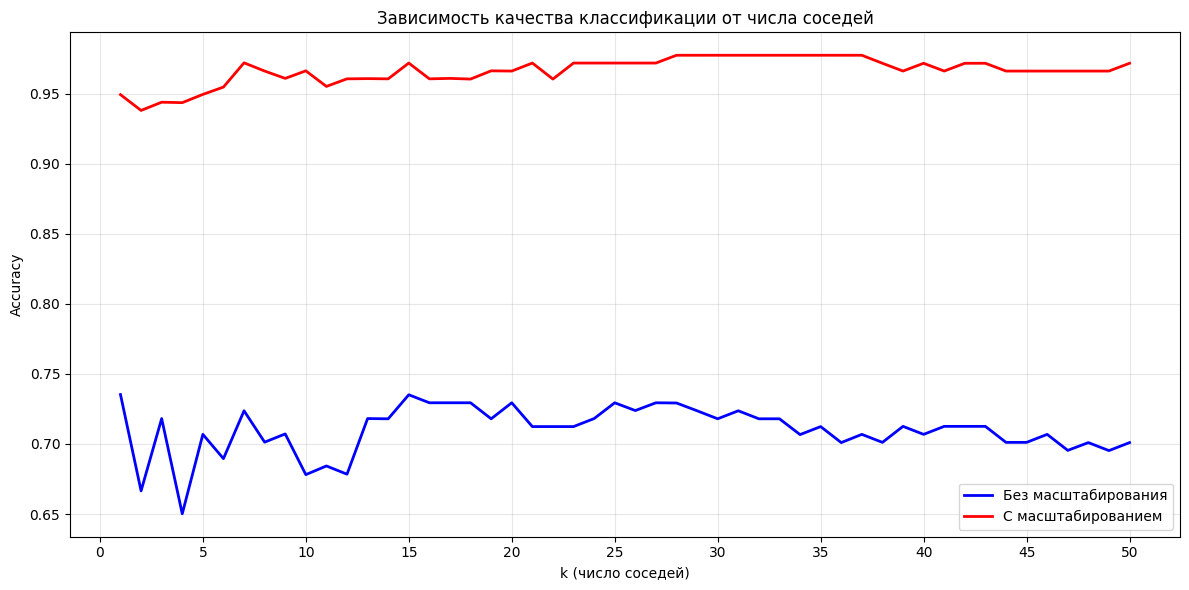

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(k_val, accuracy_scores, 'b-', label='Без масштабирования', linewidth=2)
plt.plot(k_val, accuracy_scores_scaled, 'r-', label='С масштабированием', linewidth=2)
plt.xlabel('k (число соседей)')
plt.ylabel('Accuracy')
plt.title('Зависимость качества классификации от числа соседей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 51, 5))
plt.tight_layout()
plt.show()

In [28]:
print("Ответы:")
print(f"Оптимальное k: {best_k_without_scale}")
print(f"Качество: {best_accuracy_without_scale}")
print(f"Оптимальное k после масшатибрования: {best_k_without_scale}")
print(f"Качество: {best_accuracy_without_scale}")

Ответы:
Оптимальное k: 28
Качество: 0.9773015873015873
Оптимальное k после масшатибрования: 28
Качество: 0.9773015873015873
